In [19]:
import os
import sys

project_root = os.path.abspath("..")   # đi lên 1 cấp từ notebooks về root project
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: c:\Users\A Fee\Desktop\Workspace\AI_projects\Student_Performance_Predictor


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.feature_engineering import add_new_features
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [21]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# Importing Data

In [22]:
df = pd.read_csv('../data/Student_Performance.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Data Cleaning & Preprocessing

In [23]:
df.shape

(6607, 20)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [25]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [26]:
top1_students = df[df['Exam_Score'].between(90, 100)]
print(f"Số lượng sinh viên đạt điểm từ 90 - 100: {len(top1_students)}")
top2_students = df[df['Exam_Score'].between(80,89)]
print(f"Số lượng sinh viên đạt điểm từ 80 - 89: {len(top2_students)}")
top3_students = df[df['Exam_Score'].between(70,79)]
print(f"Số lượng sinh viên đạt điểm từ 70 - 79: {len(top3_students)}")
top4_students = df[df['Exam_Score'] < 70]
print(f"Số lượng sinh viên đạt điểm < 70: {len(top4_students)}")


Số lượng sinh viên đạt điểm từ 90 - 100: 21
Số lượng sinh viên đạt điểm từ 80 - 89: 26
Số lượng sinh viên đạt điểm từ 70 - 79: 1577
Số lượng sinh viên đạt điểm < 70: 4982


In [27]:
df = df.drop_duplicates()
df = df[df['Exam_Score'] <= 100]
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

# Splitting Data

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from src.feature_engineering import add_new_features

# =========================================================
# 1. CHIA DỮ LIỆU GỐC (RAW SPLIT)
# =========================================================
# Giữ nguyên bản gốc để ném vào Pipeline sau này
X = df.drop(columns='Exam_Score')
y = df['Exam_Score']

# Chia tỷ lệ 80/20, dùng random_state để kết quả đồng nhất
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 2. TẠO TẬP DỮ LIỆU PHỤC VỤ PHÂN TÍCH (ANALYSIS SET)
# =========================================================
# Tập này dùng để chạy EDA, tính ANOVA/Mutual Info và lọc VIF
# Chúng ta chạy hàm add_new_features thủ công CHỈ trên tập này
X_train_analysis = add_new_features(X_train_raw.copy())
# 3. Tạo bản Analysis cho Test (Thêm dòng này nè Phi!)
X_test_analysis = add_new_features(X_test_raw.copy())

# Kiểm tra nhanh dữ liệu
print(f"📊 Kích thước tập Train thô: {X_train_raw.shape}")
print(f"🚀 Kích thước tập Train sau khi thêm biến: {X_train_analysis.shape}")
print(f"🔍 Số lượng dòng trùng lặp: {X_train_analysis.duplicated().sum()}")

# =========================================================
# 3. LƯU Ý CHO CÁC BƯỚC TIẾP THEO
# =========================================================
"""
Lộ trình sử dụng:
- Dùng X_train_analysis để tìm danh sách 'final_columns_raw' (qua VIF & Hybrid Selection).
- Khi chạy Optuna/Fit Model: Sử dụng X_train_raw (Pipeline sẽ tự gọi add_new_features).
- Khi chấm điểm: Sử dụng X_test_raw (Pipeline sẽ tự xử lý từ A-Z).
"""

📊 Kích thước tập Train thô: (5284, 19)
🚀 Kích thước tập Train sau khi thêm biến: (5284, 22)
🔍 Số lượng dòng trùng lặp: 0


"\nLộ trình sử dụng:\n- Dùng X_train_analysis để tìm danh sách 'final_columns_raw' (qua VIF & Hybrid Selection).\n- Khi chạy Optuna/Fit Model: Sử dụng X_train_raw (Pipeline sẽ tự gọi add_new_features).\n- Khi chấm điểm: Sử dụng X_test_raw (Pipeline sẽ tự xử lý từ A-Z).\n"

In [29]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

# --- NHÓM 1: CỘT SỐ (NUMERICAL) ---
new_engineered_features = ['Study_Efficiency', 'Total_Study_Time', 'Engagement_Index']
original_num = X_train_analysis.select_dtypes(include=['number']).columns.tolist()

# Loại bỏ 3 biến mới ra khỏi danh sách gốc (nếu lỡ có) để tránh lặp lại
num_features_raw = [col for col in original_num if col not in new_engineered_features]
full_num_features = num_features_raw + new_engineered_features

# --- NHÓM 2: NHỊ PHÂN/ĐỊNH DANH (BINARY/ONE-HOT) ---
bin_features_master = [
    'Extracurricular_Activities', 'Internet_Access', 
    'Learning_Disabilities', 'Gender', 'School_Type'
]

# --- NHÓM 3: THỨ BẬC (ORDINAL) ---
ord_features_master = [
    'Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 
    'Family_Income', 'Teacher_Quality', 'Peer_Influence', 
    'Parental_Education_Level', 'Distance_from_Home'
]

# Bảng cấp độ tương ứng (Thứ tự phải khớp 1:1 với ord_features_master)
ord_categories_master = [['missing', 'Low', 'Medium', 'High']] * 5 + \
                        [['missing', 'Negative', 'Neutral', 'Positive'],
                         ['missing', 'High School', 'College', 'Postgraduate'],
                         ['missing', 'Near', 'Moderate', 'Far']]

print(f"✅ Đã khởi tạo Master Lists: {len(full_num_features)} Số, {len(ord_features_master)} Thứ bậc, {len(bin_features_master)} Nhị phân.")


✅ Đã khởi tạo Master Lists: 9 Số, 8 Thứ bậc, 5 Nhị phân.


## Phân chia các đặc trưng phân loại và đặc trưng số

In [30]:
num_features = X_train_analysis.select_dtypes(include=np.number).columns
cat_features = X_train_analysis.select_dtypes(exclude=np.number).columns

print("Danh sách các đặc trưng số: ", num_features)
print("Danh sách các đặc trưng phân loại: ", cat_features)


Danh sách các đặc trưng số:  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Study_Efficiency',
       'Total_Study_Time', 'Engagement_Index'],
      dtype='object')
Danh sách các đặc trưng phân loại:  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


# Exploratory Data Analysis

## Historgram

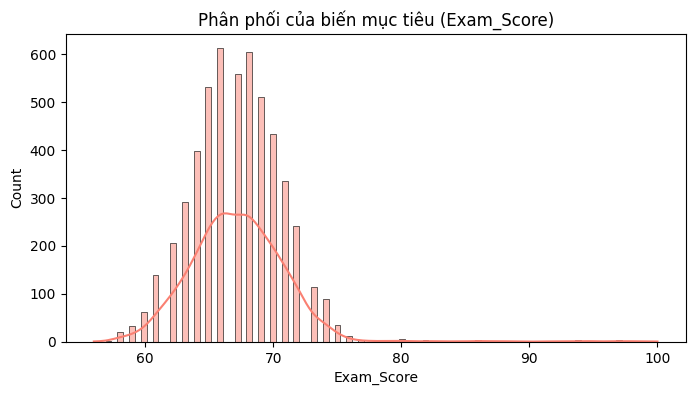

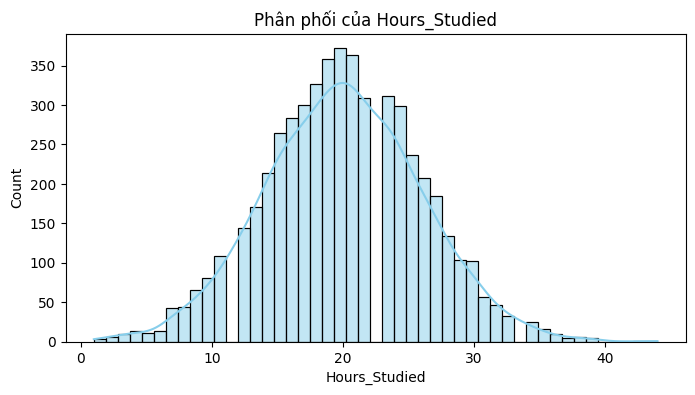

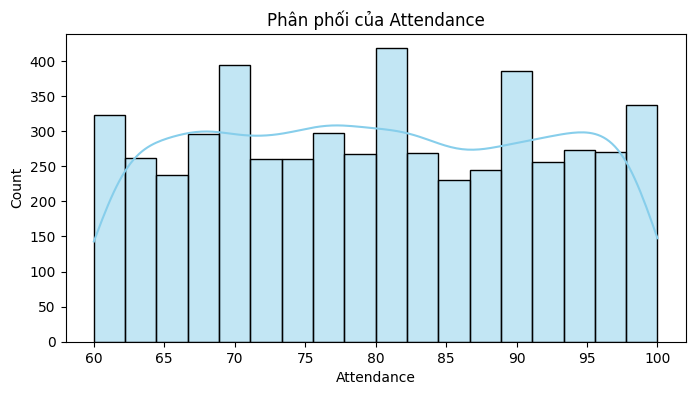

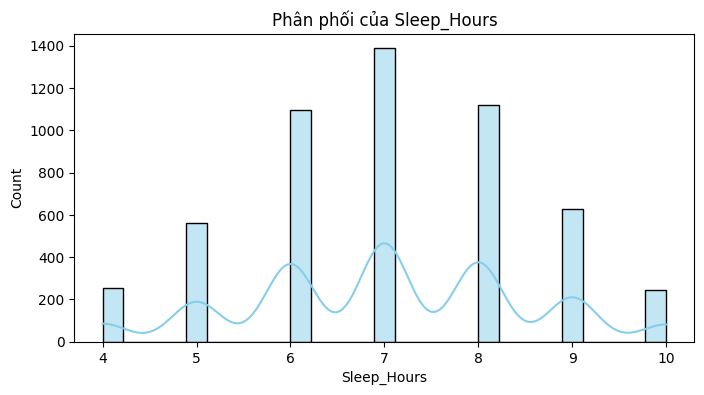

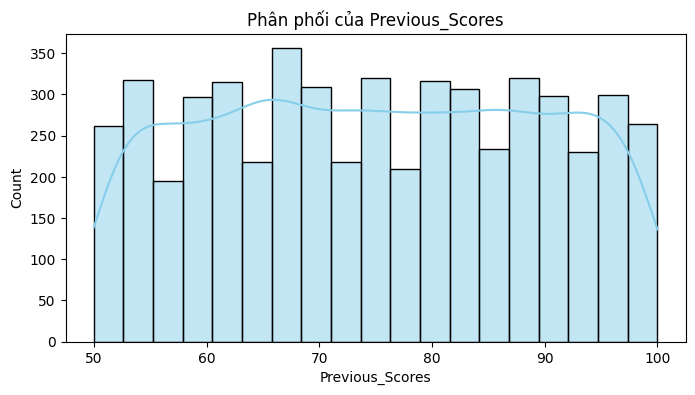

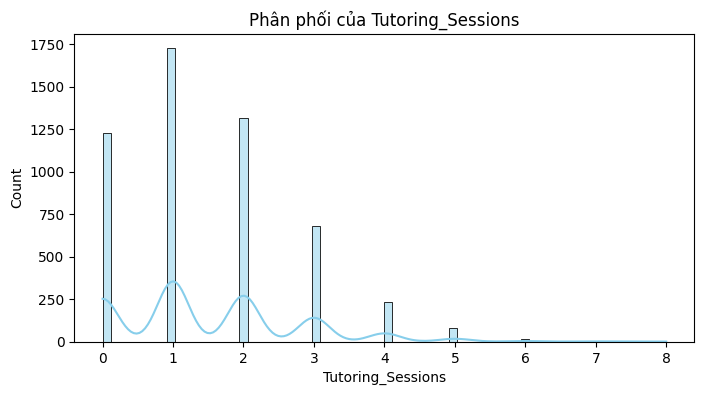

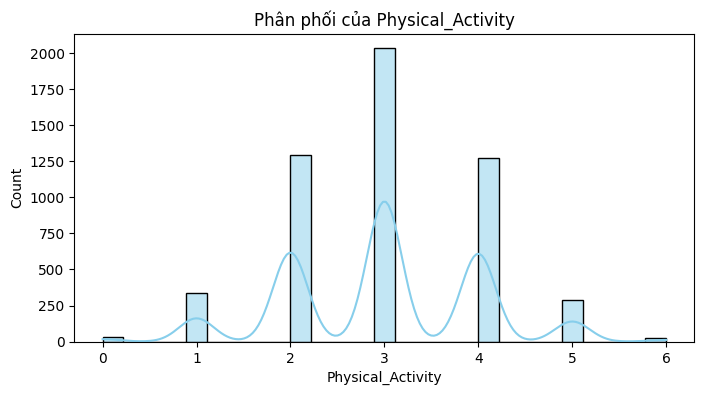

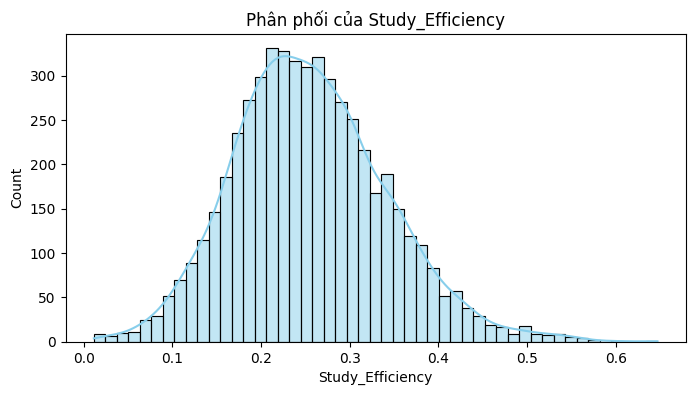

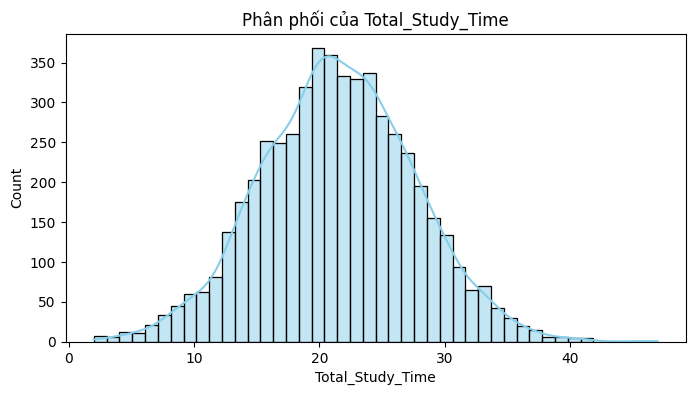

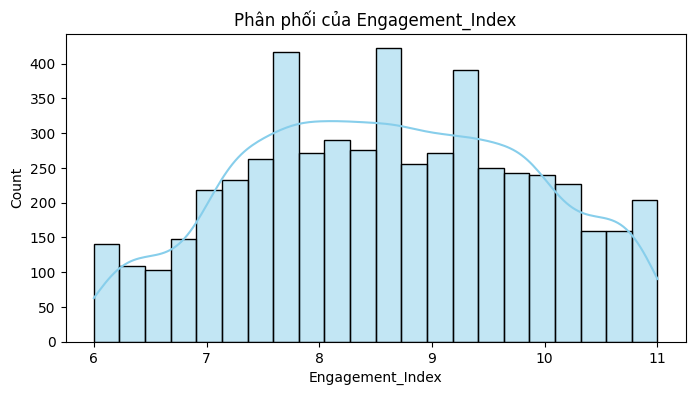

In [31]:
# 1. Vẽ biến mục tiêu trước
plt.figure(figsize=(8, 4))
sns.histplot(y_train, kde=True, color='salmon')
plt.title("Phân phối của biến mục tiêu (Exam_Score)")
plt.show()

# 2. Lặp qua danh sách TỔNG (full_num_features) để không sót cột nào
for i in num_features:
    # Kiểm tra xem cột i có thực sự nằm trong DataFrame không để tránh lỗi
    if i in X_train_analysis.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(X_train_analysis[i], kde=True, color='skyblue')
        plt.title(f"Phân phối của {i}")
        plt.show()
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy cột {i} trong X_train_analysis")

## Barplot

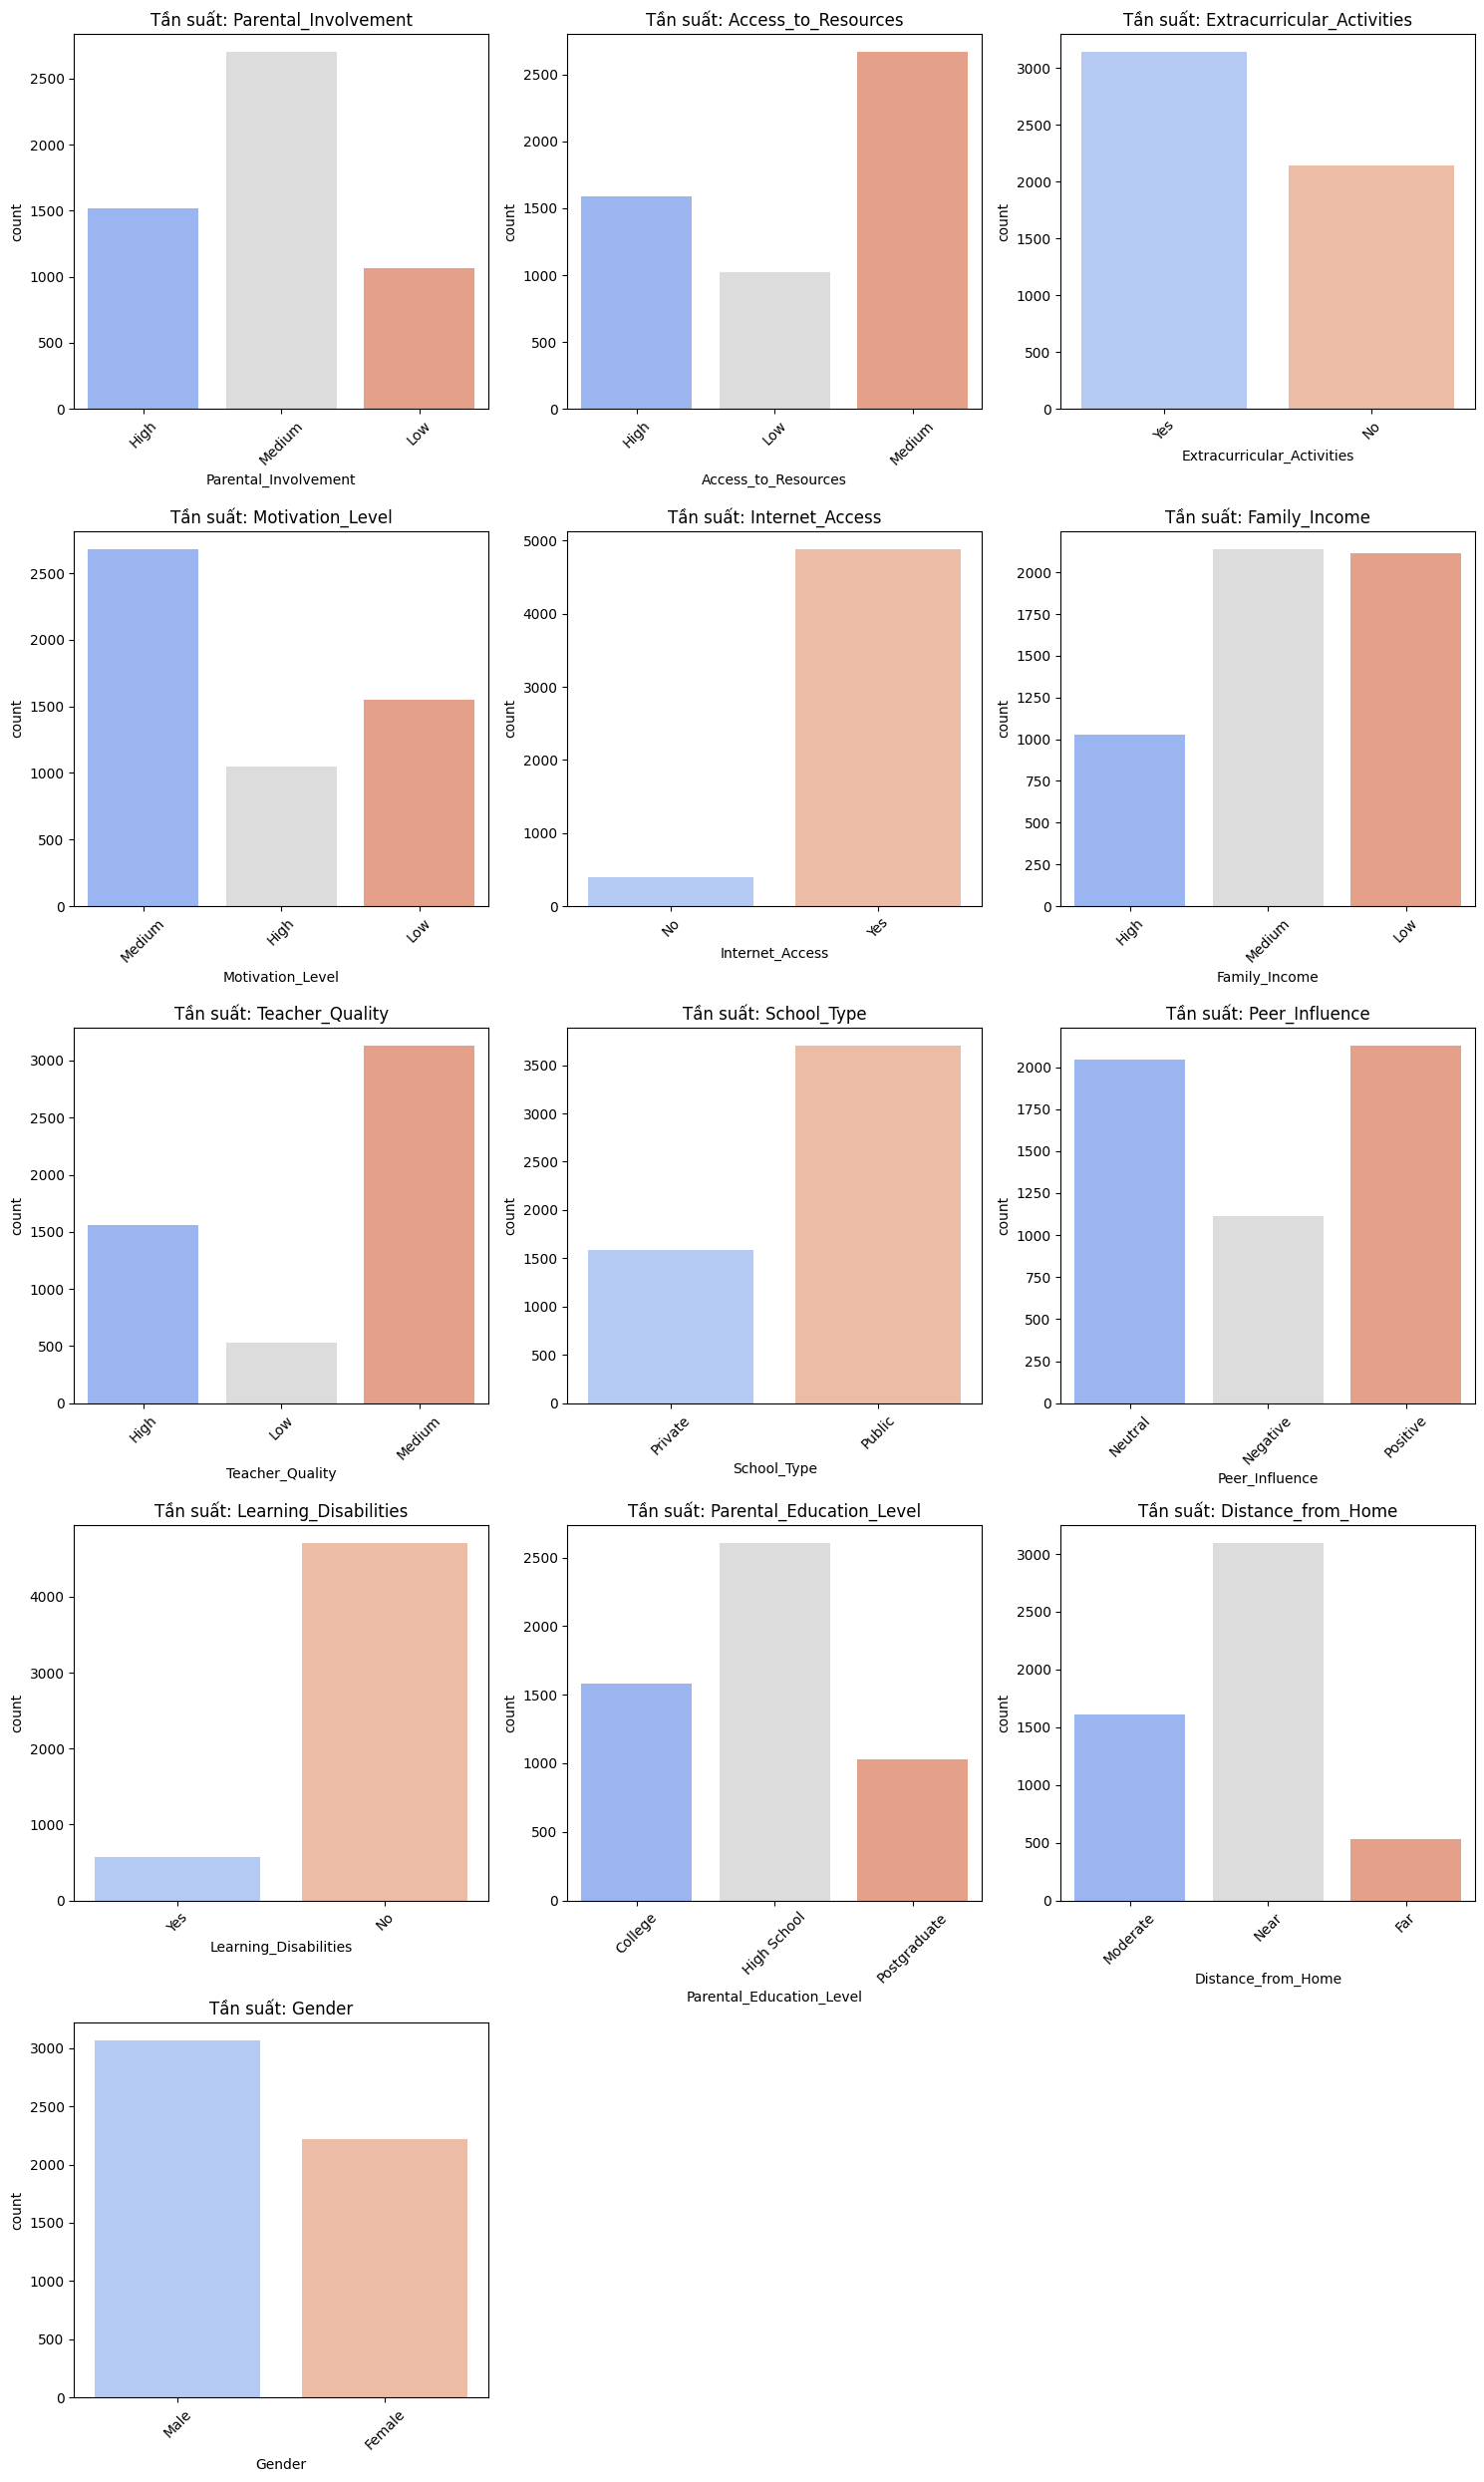

In [32]:
import math

n = len(cat_features)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Vẽ biểu đồ
    sns.countplot(data=X_train_analysis, x=col, ax=axes[i], palette='coolwarm', hue=col)
    
    # Ẩn legend thừa trên từng ô
    if axes[i].get_legend():
        axes[i].get_legend().remove()
        
    axes[i].set_title(f"Tần suất: {col}")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

# Xóa các ô trống
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Boxplot

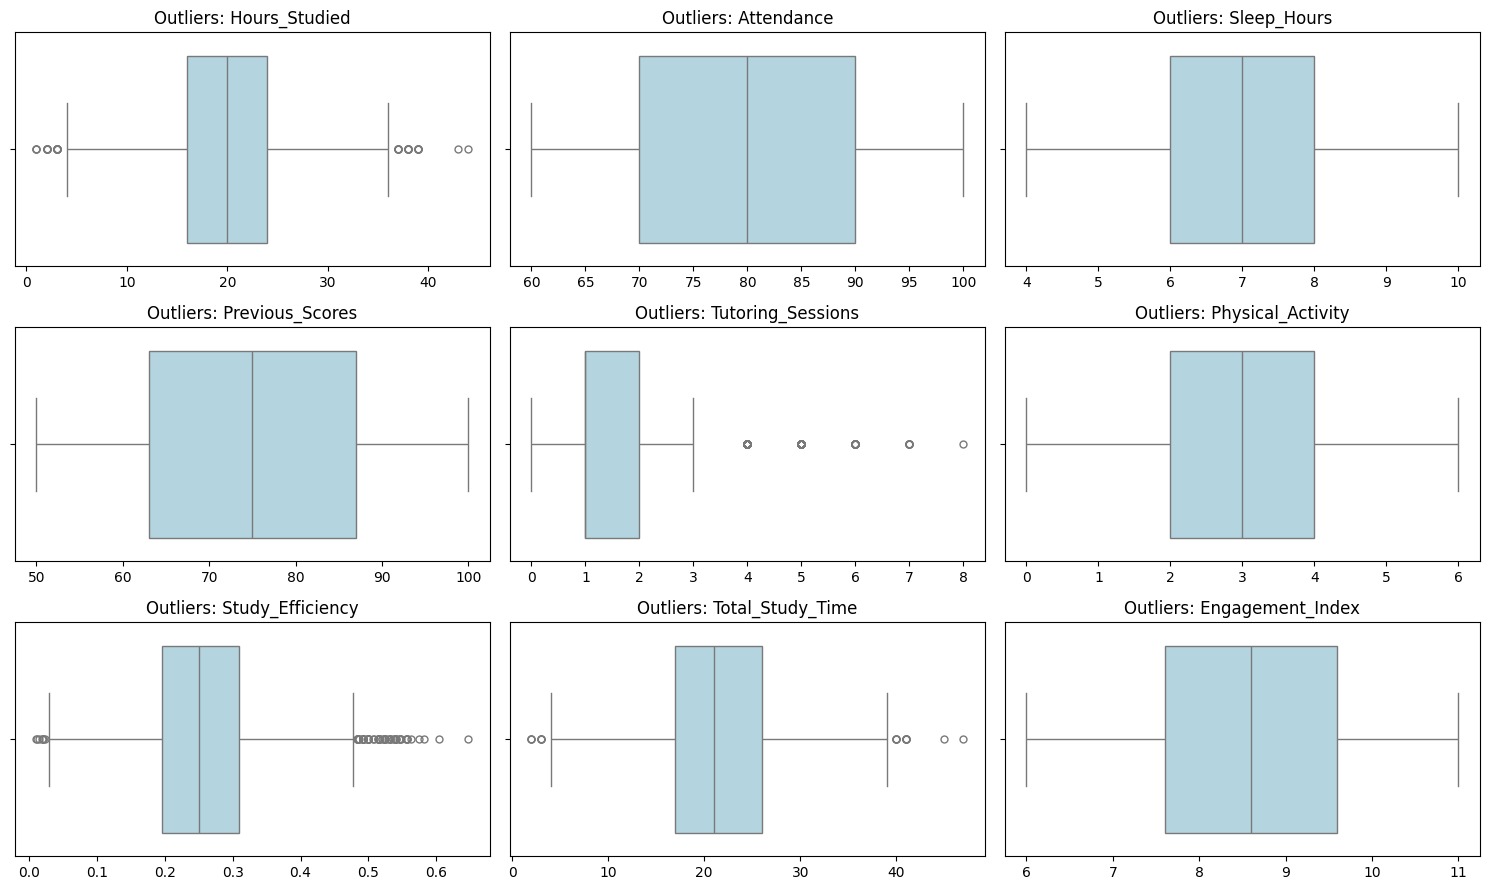

In [33]:
import math

# Dùng num_features (đã loại bỏ Exam_Score)
n = len(num_features)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # Vẽ Boxplot nằm ngang
    sns.boxplot(data=X_train_analysis, x=col, ax=axes[i], color='lightblue', fliersize=5)
    axes[i].set_title(f'Outliers: {col}')
    axes[i].set_xlabel("")

# Xóa các ô thừa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Regplot + LOWESS

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

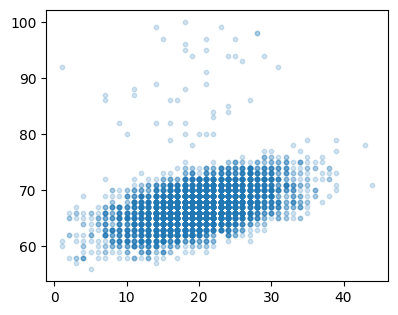

In [ ]:
# Tạo một bản copy tạm thời để vẽ (tránh lỗi lệch index)
plot_df = pd.concat([X_train_analysis, y_train], axis=1)
n = len(num_features)
n_cols = 3 
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.regplot(
        x=col, 
        y='Exam_Score',
        data=plot_df, 
        scatter_kws={'alpha': 0.2, 's': 10},
        line_kws={'color': 'red', 'lw': 2}
    )
        data=plot_df, 
        lowess=True, 
        scatter_kws={'alpha': 0.2, 's': 10}, # Giảm alpha và size để bớt rối
        line_kws={'color': 'red', 'lw': 2}
    )
    plt.title(f"Mối quan hệ: {col}")
    plt.xlabel(col)
    plt.ylabel('Exam_Score')

plt.suptitle('Phân tích tính Tuyến tính (LOWESS Regplots)', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Pearson's Correlation (cho biến liên tục)
Kiểm tra biến số có ảnh hưởng đến Target không 

In [ ]:
# Thiết lập kích thước vàng (ví dụ 10 inch x 6 inch)
temp_df = pd.concat([X_train_analysis, y_train], axis=1)

plt.figure(figsize=(10, 6), dpi=100) # 1000x600 pixels
corr = temp_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

## Mutual Information (MI)
Mutual Information đo mức độ phụ thuộc tổng quát giữa feature và biến mục tiêu, cho phép phát hiện cả các mối quan hệ phi tuyến mà correlation không thể nắm bắt.

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

# =================================================================
# PHẦN: TÍNH TOÁN MUTUAL INFORMATION (LỌC BIẾN PHI TUYẾN)

# 1. Tạo bản sao dữ liệu Train để tính toán (Chống Data Leakage)
# Chúng ta không thao tác trực tiếp trên X_train để giữ dữ liệu sạch cho Pipeline
X_mi = X_train_analysis.copy()
y_mi = y_train.copy()

# 2. Xử lý giá trị thiếu (Imputation) cho các biến phân loại
# MI không chấp nhận giá trị NaN, nên ta điền tạm thời bằng chuỗi 'Missing'
X_mi[cat_features] = X_mi[cat_features].fillna('Missing')

# 3. Mã hóa TẠM THỜI (Temporary Encoding) cho toàn bộ biến chữ
# Lưu ý: Ở bước MI, dùng OrdinalEncoder cho cả Nominal và Binary là ĐÚNG.
# Vì MI chỉ cần phân biệt các nhóm (unique values), không quan tâm đến thứ tự hay khoảng cách.
temp_label_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_mi[cat_features] = temp_label_encoder.fit_transform(X_mi[cat_features].astype(str))

# 4. Tạo "Mặt nạ" (Discrete Mask) để báo cho hàm MI biết cột nào là biến phân loại
# Điều này cực kỳ quan trọng để hàm MI tính toán chính xác theo phân phối rời rạc
discrete_mask = [col in cat_features for col in X_mi.columns]

# 5. Tính toán điểm Mutual Information (MI Score)
# random_state=42 giúp kết quả nhất quán mỗi khi chạy lại
mi_scores = mutual_info_regression(
    X_mi, y_mi, 
    discrete_features=discrete_mask, 
    random_state=42
)

# 6. Đóng gói kết quả vào DataFrame và sắp xếp từ cao đến thấp
mi_df = pd.DataFrame({
    'Feature': X_mi.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 7. Trực quan hóa kết quả bằng biểu đồ Barplot
plt.figure(figsize=(10, 8))

# 1. Vẽ biểu đồ và gán vào biến ax để thao tác trên các cột
ax = sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='viridis')

# 2. Thêm số vào đầu mỗi cột (Data Annotation)
# padding=3 để đẩy chữ ra xa cột một chút
# fmt='%.4f' để lấy 4 chữ số thập phân (vì MI Score thường khá nhỏ)
ax.bar_label(ax.containers[0], padding=3, fmt='%.4f', fontsize=10)

# 3. Trang trí thêm
plt.title('Mức độ đóng góp thông tin (Mutual Information) vào Exam_Score', fontsize=14, pad=20)
plt.xlabel('MI Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Nới rộng trục x một chút để con số không bị dính vào mép biểu đồ
plt.xlim(0, mi_df['MI_Score'].max() * 1.15) 

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## ANOVA Test (cho biến phân loại)
Kiểm tra biến phân loại có ảnh hưởng đến Target không 

In [ ]:
from scipy.stats import f_oneway

# =================================================================
# PHẦN: KIỂM ĐỊNH ANOVA (PHÂN TÍCH Ý NGHĨA BIẾN PHÂN LOẠI)
# =================================================================

# 1. Chuẩn bị dữ liệu từ tập TRAIN để đảm bảo tính khách quan (Chống Leakage)
temp_df = pd.concat([X_train_analysis, y_train], axis=1)
target_col = 'Exam_Score'
anova_list = []

print("⏳ Đang tiến hành kiểm định ANOVA...")

for col in cat_features:
    # 2. Gom nhóm và Lọc sạch mẫu nhỏ (Tránh SmallSampleWarning)
    # Một nhóm phải có ít nhất 2 mẫu để tính được phương sai nội tại
    valid_groups = []
    for val in temp_df[col].unique():
        group = temp_df[temp_df[col] == val][target_col].dropna()
        if len(group) > 1:
            valid_groups.append(group)
    
    # 3. Thực hiện kiểm định f_oneway nếu có ít nhất 2 nhóm để so sánh
    if len(valid_groups) >= 2:
        try:
            stat, p = f_oneway(*valid_groups)
            
            # Xử lý p-value cực nhỏ để tránh lỗi toán học khi tính Log10
            # Ngưỡng 1e-15 là đủ nhỏ để thể hiện sự khác biệt cực lớn
            p_safe = max(p, 1e-15) if not np.isnan(p) else np.nan
            
            anova_list.append({
                'Feature': col, 
                'p_value': p, 
                'Significance_Score': -np.log10(p_safe)
            })
        except Exception:
            continue

# 4. Đóng gói vào DataFrame và sắp xếp theo độ quan trọng
anova_df = pd.DataFrame(anova_list).dropna()
anova_df = anova_df.sort_values('Significance_Score', ascending=False)

# 5. Trực quan hóa kết quả
plt.figure(figsize=(12, 10)) 
ax = sns.barplot(
    data=anova_df, 
    x='Significance_Score', 
    y='Feature', 
    palette='magma'
)

# 6. Ghi số liệu (Score & p-value) trực tiếp lên biểu đồ
for i, (score, p) in enumerate(zip(anova_df['Significance_Score'], anova_df['p_value'])):
    text_color = 'darkgreen' if p <= 0.05 else 'darkred'
    # Hiển thị cả Score và p-value dạng số mũ
    display_text = f'Score: {score:.2f} | p: {p:.2e}'
    
    ax.text(
        score + 0.1, i, 
        display_text, 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color=text_color
    )

# 7. TRANG TRÍ VÀ HIỂN THỊ (Gộp tất cả vào đây)
# Đường giới hạn p = 0.05
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='Ngưỡng tin cậy (p=0.05)')

plt.title('Phân tích ANOVA: Tầm ảnh hưởng của các biến phân loại', fontsize=16, pad=25)
plt.xlabel('Significance Score [-log10(p-value)]', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Nới rộng trục X 1.5 lần để không mất chữ
plt.xlim(0, anova_df['Significance_Score'].max() * 1.5) 

plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()

# Lệnh hiển thị cuối cùng
plt.show()

print("✅ Đã hoàn thành phân tích ANOVA.")

## Kiểm tra tính đơn điệu của biến thứ bậc

In [ ]:
# BƯỚC 4: ORDINAL MONOTONICITY (KIỂM TRA TÍNH LOGIC THỨ BẬC)
ordinal_mapping = {
    'Parental_Involvement': ['Low', 'Medium', 'High'],
    'Access_to_Resources': ['Low', 'Medium', 'High'],
    'Motivation_Level': ['Low', 'Medium', 'High'],
    'Family_Income': ['Low', 'Medium', 'High'],
    'Teacher_Quality': ['Low', 'Medium', 'High'],
    'Peer_Influence': ['Negative', 'Neutral', 'Positive'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home': ['Near', 'Moderate', 'Far']
}
# =================================================================
print("🔍 Đang kiểm tra tính đơn điệu của các biến Ordinal...")
for col, order in ordinal_mapping.items():
    if col in temp_df.columns:
        plt.figure(figsize=(8, 5))
        # Vẽ Boxplot kết hợp Pointplot để thấy đường xu hướng (Trend line)
        sns.boxplot(data=temp_df, x=col, y=target_col, order=order, palette='Pastel1', showfliers=False)
        sns.pointplot(data=temp_df, x=col, y=target_col, order=order, color='red', markers='D', linestyles='--')
        
        plt.title(f'3. Monotonicity Check: {col}', fontsize=12)
        plt.grid(axis='y', alpha=0.3)
        plt.show()

## Hiệu ứng Tương tác (Interaction Plot)

In [ ]:
# 1. Chuẩn bị dữ liệu
temp_df = pd.concat([X_train_analysis, y_train], axis=1)

def plot_interaction_pro(df, feat1, feat2, target, order1=None, hue_order=None):
    plt.figure(figsize=(12, 7))
    df_plot = df.copy()
    
    # --- XỬ LÝ TRỤC X (FEAT1) ---
    if pd.api.types.is_numeric_dtype(df_plot[feat1]):
        # Chỉ khi là số mới chia bin
        df_plot[feat1] = pd.qcut(df_plot[feat1], q=4, duplicates='drop')
        x_order = sorted(df_plot[feat1].unique())
        xlabel = f"{feat1} (Phân nhóm theo tứ phân vị)"
    else:
        # Nếu là chữ (Parental_Involvement) thì cứ để nguyên để vẽ
        x_order = None # Hoặc định nghĩa thứ tự cụ thể ['Low', 'Medium', 'High']
        xlabel = feat1

    # --- VẼ BIỂU ĐỒ ---
    sns.pointplot(
        data=df_plot, 
        x=feat1, 
        y=target, 
        hue=feat2,
        order=x_order, 
        hue_order=hue_order,
        palette='magma', 
        capsize=.1, 
        markers=["o", "s", "D"],
        linestyles=["-", "--", "-."]
    )

    # --- TRANG TRÍ ---
    plt.title(f'Phân tích Hiệu ứng Tương tác: {feat1} & {feat2}', fontsize=15, pad=20)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(f'Trung bình {target}', fontsize=12)
    plt.legend(title=feat2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

# =================================================================
# GỌI HÀM KIỂM TRA (Đúng tham số)
# =================================================================

# Cặp 1: Hai biến phân loại mạnh nhất
print("👉 Đang phân tích: Parental_Involvement & Access_to_Resources")
plot_interaction_pro(
    temp_df, 
    feat1='Parental_Involvement', 
    feat2='Access_to_Resources', 
    target='Exam_Score',
    order1=['Low', 'Medium', 'High'],
    hue_order=['Low', 'Medium', 'High']
)

# Cặp 2: Biến số mạnh và Biến phân loại
print("👉 Đang phân tích: Hours_Studied & Motivation_Level")
plot_interaction_pro(
    temp_df, 
    feat1='Hours_Studied', 
    feat2='Motivation_Level', 
    target='Exam_Score',
    hue_order=['Low', 'Medium', 'High']
)

# Cặp 3: Biến số mạnh nhất và Tài nguyên
print("👉 Đang phân tích: Attendance & Access_to_Resources")
plot_interaction_pro(
    temp_df, 
    feat1='Attendance', 
    feat2='Access_to_Resources', 
    target='Exam_Score',
    hue_order=['Low', 'Medium', 'High']
)

# Scaling + Encoding + Feature Selection

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

print("=== DEBUG CELL 48 ===")
print("X_train_analysis columns:")
print(X_train_analysis.columns.tolist())

print("\nMaster lists:")
print("full_num_features:", full_num_features)
print("bin_features_master:", bin_features_master)
print("ord_features_master:", ord_features_master)

# =========================================================
# 1. BỘ LỌC ĐỘNG: CHỈ GIỮ CỘT THẬT SỰ TỒN TẠI
# =========================================================
current_num = [c for c in full_num_features if c in X_train_analysis.columns]
current_bin = [c for c in bin_features_master if c in X_train_analysis.columns]

current_ord = []
current_ord_categories = []

for i, col in enumerate(ord_features_master):
    if col in X_train_analysis.columns:
        current_ord.append(col)
        current_ord_categories.append(ord_categories_master[i])

print("\nMatched groups INSIDE cell 48:")
print("current_num:", current_num)
print("current_bin:", current_bin)
print("current_ord:", current_ord)

if len(current_num) + len(current_bin) + len(current_ord) == 0:
    raise ValueError("All matched groups are empty inside cell 48.")

# =========================================================
# 2. BUILD PREPROCESSOR
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            current_num
        ),
        (
            "ord",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OrdinalEncoder(categories=current_ord_categories))
            ]),
            current_ord
        ),
        (
            "bin",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
            ]),
            current_bin
        )
    ],
    remainder="drop"
)

print("\n✅ Preprocessor built successfully.")
print("preprocessor.transformers =")
print(preprocessor.transformers)

In [ ]:
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn import set_config

# 1. Cấu hình trả về DataFrame
set_config(transform_output="pandas")

# =========================================================
# DEBUG TRƯỚC KHI PREPROCESS
# =========================================================
print("=== DEBUG BEFORE PREPROCESSING ===")
print("Type of X_train_analysis:", type(X_train_analysis))
print("Type of X_test_analysis :", type(X_test_analysis))

print("X_train_analysis shape:", X_train_analysis.shape)
print("X_test_analysis shape :", X_test_analysis.shape)

print("\nX_train_analysis columns:")
print(X_train_analysis.columns.tolist())

print("\nPreprocessor transformers:")
print(preprocessor.transformers)

print("\n=== CHECK FEATURE GROUPS INSIDE PREPROCESSOR ===")
for name, transformer, cols in preprocessor.transformers:
    print(f"{name}: {len(cols)} columns -> {cols}")

if X_train_analysis.shape[1] == 0:
    raise ValueError("X_train_analysis has 0 columns.")

if len(preprocessor.transformers) == 0:
    raise ValueError("Preprocessor has no transformers.")

# =========================================================
# BƯỚC 1: TIỀN XỬ LÝ & TÍNH TOÁN CHỈ SỐ
# =========================================================
X_train_encoded = preprocessor.fit_transform(X_train_analysis)
X_test_encoded = preprocessor.transform(X_test_analysis)

print("\n✅ Encoded shapes:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded :", X_test_encoded.shape)

if X_train_encoded.shape[1] == 0:
    raise ValueError("Encoded training data has 0 columns after preprocessing.")

# Tính toán ANOVA (p-value) và Mutual Information
_, p_values = f_regression(X_train_encoded, y_train)
mi_scores = mutual_info_regression(X_train_encoded, y_train, random_state=42)

# Tạo bảng tổng hợp
selection_df = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "p_value": p_values,
    "MI_Score": mi_scores
})

# =========================================================
# BƯỚC 2: LÀM SẠCH TÊN BIẾN (CHỦ YẾU ĐỂ HIỂN THỊ)
# =========================================================
def clean_feature_names(name):
    clean_name = name.split("__")[-1]

    suffixes = [
        "_Yes", "_No",
        "_Male", "_Female",
        "_Public", "_Private",
        "_Urban", "_Rural"
    ]

    for s in suffixes:
        if clean_name.endswith(s):
            clean_name = clean_name.replace(s, "")

    return clean_name

selection_df["Clean_Feature"] = selection_df["Feature"].apply(clean_feature_names)
selection_df = selection_df.sort_values(by="MI_Score", ascending=False).reset_index(drop=True)

dup_clean = selection_df["Clean_Feature"][selection_df["Clean_Feature"].duplicated()].unique().tolist()
print("Duplicated clean feature names:", dup_clean)

# =========================================================
# BƯỚC 3: TRỰC QUAN HÓA
# =========================================================
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

ax1.bar(
    selection_df["Clean_Feature"],
    selection_df["MI_Score"],
    color="#5cb85c",
    alpha=0.7,
    label="Mutual Info (Càng cao càng tốt)"
)

ax2.plot(
    selection_df["Clean_Feature"],
    selection_df["p_value"],
    color="#d9534f",
    marker="o",
    linewidth=2,
    label="p-value (Càng thấp càng tốt)"
)

ax1.axhline(y=0.01, color="green", linestyle="--", alpha=0.5)
ax2.axhline(y=0.05, color="red", linestyle="--", alpha=0.5)

ax1.tick_params(axis='x', labelrotation=45)
plt.xticks(ha='right', fontsize=10)

ax1.set_ylabel("Lượng thông tin (MI Score)", fontsize=12, fontweight="bold", color="green")
ax2.set_ylabel("Ý nghĩa thống kê (p-value)", fontsize=12, fontweight="bold", color="red")
plt.title("PHÂN TÍCH ĐẶC TRƯNG: HYBRID SELECTION (ANOVA vs MI)", fontsize=15, pad=20)

lns1, labs1 = ax1.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, labs1 + labs2, loc="upper right", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

# =========================================================
# BƯỚC 4: LỌC FEATURE THEO HYBRID RULE
# =========================================================
selected_mask = (selection_df["p_value"] < 0.05) | (selection_df["MI_Score"] > 0.01)

selected_df = selection_df[selected_mask].copy()
encoded_selected_features = selected_df["Feature"].tolist()

X_train_selected = X_train_encoded[encoded_selected_features].copy()
X_test_selected = X_test_encoded[encoded_selected_features].copy()

print(f"✅ Sau hybrid filtering còn {len(encoded_selected_features)} encoded features.")

# =========================================================
# BƯỚC 5: LỌC BỚT FEATURE DƯ THỪA BẰNG TƯƠNG QUAN
# =========================================================
corr_matrix = X_train_selected.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_threshold = 0.85
features_to_drop = []

for col in upper_triangle.columns:
    high_corr_features = upper_triangle.index[upper_triangle[col] > corr_threshold].tolist()

    for row_feature in high_corr_features:
        row_info = selected_df[selected_df["Feature"] == row_feature]
        col_info = selected_df[selected_df["Feature"] == col]

        if row_info.empty or col_info.empty:
            continue

        row_mi = row_info["MI_Score"].values[0]
        col_mi = col_info["MI_Score"].values[0]

        row_p = row_info["p_value"].values[0]
        col_p = col_info["p_value"].values[0]

        if row_mi > col_mi:
            drop_feature = col
        elif row_mi < col_mi:
            drop_feature = row_feature
        else:
            drop_feature = col if row_p > col_p else row_feature

        if drop_feature not in features_to_drop:
            features_to_drop.append(drop_feature)

X_train_clean = X_train_selected.drop(columns=features_to_drop, errors="ignore")
X_test_clean = X_test_selected.drop(columns=features_to_drop, errors="ignore")

print("✅ Corr redundancy filtering completed.")
print(f"📉 Dropped {len(features_to_drop)} highly correlated features:")
print(features_to_drop)

print(f"\n✅ Final selected feature count: {X_train_clean.shape[1]}")
print("🎯 Final selected encoded features:")
print(X_train_clean.columns.tolist())

display_feature_names = [clean_feature_names(col) for col in X_train_clean.columns]
print("\n🖼️ Display names for reporting:")
print(display_feature_names)


print("\nShapes after filtering:")
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected :", X_test_selected.shape)
print("X_train_clean   :", X_train_clean.shape)
print("X_test_clean    :", X_test_clean.shape)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# =========================================================
# 1. MAP ENCODED FEATURES -> RAW FEATURES
# =========================================================
def encoded_to_raw_feature(feature_name):
    raw_name = feature_name.split("__")[-1]

    known_suffixes = [
        "_Yes", "_No",
        "_Male", "_Female",
        "_Public", "_Private",
        "_Urban", "_Rural"
    ]

    for s in known_suffixes:
        if raw_name.endswith(s):
            raw_name = raw_name.replace(s, "")

    return raw_name


encoded_survivors = X_train_clean.columns.tolist()

raw_survivors = [encoded_to_raw_feature(col) for col in encoded_survivors]
raw_survivors = list(dict.fromkeys(raw_survivors))

print("✅ Encoded survivors:")
print(encoded_survivors)

print("\n✅ Raw survivors:")
print(raw_survivors)

print("\n=== DEBUG MAPPING ENCODED -> RAW ===")
for col in encoded_survivors:
    print(f"{col} -> {encoded_to_raw_feature(col)}")

# =========================================================
# 2. REBUILD RAW FEATURE GROUPS
# =========================================================
current_num = [c for c in full_num_features if c in raw_survivors]
current_bin = [c for c in bin_features_master if c in raw_survivors]

current_ord = []
current_ord_categories = []

for i, col in enumerate(ord_features_master):
    if col in raw_survivors:
        current_ord.append(col)
        current_ord_categories.append(ord_categories_master[i])

print("\n✅ Rebuilt raw feature groups:")
print("Numerical:", current_num)
print("Binary   :", current_bin)
print("Ordinal  :", current_ord)

print("\n=== DEBUG MATCH AGAINST MASTER LISTS ===")
print("Matched numerical:", [c for c in full_num_features if c in raw_survivors])
print("Matched binary   :", [c for c in bin_features_master if c in raw_survivors])
print("Matched ordinal  :", [c for c in ord_features_master if c in raw_survivors])

total_features = len(current_num) + len(current_ord) + len(current_bin)
print("Total raw selected features:", total_features)

if total_features == 0:
    raise ValueError(
        "No raw features left after mapping encoded survivors to raw features. "
        "Check encoded_to_raw_feature() or feature selection thresholds."
    )

# =========================================================
# 3. REBUILD SELECTED PREPROCESSOR
# =========================================================
preprocessor_selected = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            current_num
        ),
        (
            "ord",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OrdinalEncoder(categories=current_ord_categories))
            ]),
            current_ord
        ),
        (
            "bin",
            Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                ("enc", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
            ]),
            current_bin
        )
    ],
    remainder="drop"
)

print("\n✅ preprocessor_selected created successfully.")
print(f"📊 Final raw groups: {len(current_num)} numerical | {len(current_ord)} ordinal | {len(current_bin)} binary")

In [ ]:
set_config(transform_output="pandas")

X_train_selected_encoded = preprocessor_selected.fit_transform(X_train_analysis[raw_survivors])
X_test_selected_encoded = preprocessor_selected.transform(X_test_analysis[raw_survivors])

print("✅ X_train_selected_encoded shape:", X_train_selected_encoded.shape)
print("✅ X_test_selected_encoded shape :", X_test_selected_encoded.shape)

print(X_train_selected_encoded.head())

# Filtering & VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# =========================================================
# 1. HÀM TÍNH VIF SẠCH HƠN
# =========================================================
def check_vif_optimized(X_df):
    X = X_df.copy()

    # Chỉ giữ numeric columns
    X = X.select_dtypes(include=[np.number]).copy()

    # Bỏ các cột hằng nếu có
    constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
    if constant_cols:
        print("Dropped constant columns:", constant_cols)
        X = X.drop(columns=constant_cols)

    if X.shape[1] == 0:
        raise ValueError("No numeric columns left for VIF calculation.")

    # Thêm intercept
    X_with_const = add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_with_const.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_with_const.values, i)
        for i in range(X_with_const.shape[1])
    ]

    vif_results = vif_data[vif_data["Feature"] != "const"].copy()

    # Tên hiển thị đẹp hơn
    def clean_name(x):
        name = x.split("__")[-1]
        suffixes = [
            "_Yes", "_No",
            "_Male", "_Female",
            "_Public", "_Private",
            "_Urban", "_Rural"
        ]
        for s in suffixes:
            if name.endswith(s):
                name = name.replace(s, "")
        return name

    vif_results["Display Name"] = vif_results["Feature"].apply(clean_name)

    def get_status(vif):
        if vif < 5:
            return "✅ An toàn"
        elif vif < 10:
            return "⚠️ Cảnh báo nhẹ"
        return "🚨 Đa cộng tuyến nặng"

    vif_results["Status"] = vif_results["VIF"].apply(get_status)

    return vif_results[["Feature", "Display Name", "VIF", "Status"]].sort_values(
        by="VIF", ascending=False
    )


# =========================================================
# 2. THỰC THI VIF TRÊN DỮ LIỆU ĐÃ QUA preprocessor_selected
# =========================================================
print("-" * 60)
print("🛡️ KIỂM TRA SỨC KHỎE ĐẶC TRƯNG (VIF CHECK)")
print("-" * 60)

vif_report = check_vif_optimized(X_train_selected_encoded)

display(vif_report)

high_vif_count = (vif_report["VIF"] > 5).sum()

if high_vif_count == 0:
    print("\n🎉 Tuyệt vời! Tất cả các biến đều khá độc lập, không có đa cộng tuyến đáng kể.")
else:
    print(f"\n📢 Lưu ý: Có {high_vif_count} biến có VIF > 5. Có thể cân nhắc loại bớt nếu dùng mô hình nhạy với đa cộng tuyến.")

print("-" * 60)

In [ ]:
import pandas as pd

# =========================================================
# 1. PHÂN TÍCH NHÓM ĐIỂM TRÊN TRAIN SET
# =========================================================
train_data = pd.concat([X_train_raw.copy(), y_train.copy()], axis=1)

g_90 = train_data[train_data["Exam_Score"] >= 90]
g_80 = train_data[(train_data["Exam_Score"] >= 80) & (train_data["Exam_Score"] < 90)]
g_70 = train_data[(train_data["Exam_Score"] >= 70) & (train_data["Exam_Score"] < 80)]
g_rest = train_data[train_data["Exam_Score"] < 70]

print(f"📊 Danh sách các nhóm điểm:")
print(f"90+   : {len(g_90)}")
print(f"80-89 : {len(g_80)}")
print(f"70-79 : {len(g_70)}")
print(f"<70   : {len(g_rest)}")

# Dữ liệu train dùng cho modeling
X_train_for_model = X_train_raw.copy()
y_train_for_model = y_train.copy()

print(f"\n🚀 Shape train for model: {X_train_for_model.shape}")

In [ ]:
# =========================================================
# 1. FEATURE ENGINEERING TRÊN RAW DATA
# =========================================================
X_train_for_model_eng = add_new_features(X_train_for_model.copy())
X_test_for_model_eng = add_new_features(X_test_raw.copy())

print("✅ Feature engineering completed.")
print("Train engineered shape:", X_train_for_model_eng.shape)
print("Test engineered shape :", X_test_for_model_eng.shape)

# =========================================================
# 2. CHỈ GIỮ RAW SURVIVORS
# =========================================================
X_train_for_model_eng = X_train_for_model_eng[raw_survivors].copy()
X_test_for_model_eng = X_test_for_model_eng[raw_survivors].copy()

print("\n✅ Kept only raw survivors.")
print("Train selected raw shape:", X_train_for_model_eng.shape)
print("Test selected raw shape :", X_test_for_model_eng.shape)

# =========================================================
# 3. ENCODE THE SELECTED RAW FEATURES
# =========================================================
X_train_model_encoded = preprocessor_selected.fit_transform(X_train_for_model_eng)
X_test_model_encoded = preprocessor_selected.transform(X_test_for_model_eng)

print("\n✅ Encoded data ready for model selection.")
print("Train encoded shape:", X_train_model_encoded.shape)
print("Test encoded shape :", X_test_model_encoded.shape)

# Model Selection

Nếu R² ≈ 0.2–0.3 → mối quan hệ yếu (model chưa giải thích tốt).

Nếu R² > 0.5 → khá ổn cho linear.

Nếu R² < 0.2 → nên cân nhắc mô hình khác.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================================================
# 1. TRAIN MODELS ON FINAL ENCODED TRAIN SET
# =========================================================

# 1. Linear Regression
print("🔍 [1/5] Đang đánh giá Linear Regression...")
lr_model = LinearRegression().fit(
    X_train_model_encoded,
    y_train_for_model
)

# 2. Lasso
print("🎯 [2/5] Đang tối ưu Lasso (L1)...")
lasso_grid = GridSearchCV(
    Lasso(random_state=42),
    {"alpha": [0.001, 0.01, 0.1, 1.0]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
lasso_grid.fit(
    X_train_model_encoded,
    y_train_for_model
)

# 3. Ridge
print("🛡️ [3/5] Đang tối ưu Ridge (L2)...")
ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    {"alpha": [0.1, 1.0, 10.0]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
ridge_grid.fit(
    X_train_model_encoded,
    y_train_for_model
)

# 4. Random Forest
print("🌲 [4/5] Đang tối ưu Random Forest...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {
        "n_estimators": [200],
        "max_depth": [5, 8],
        "min_samples_leaf": [5, 10],
        "max_features": [0.7, "sqrt"]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
rf_grid.fit(
    X_train_model_encoded,
    y_train_for_model
)

# 5. XGBoost
print("⚡ [5/5] Đang tối ưu XGBoost...")
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, tree_method="hist"),
    {
        "n_estimators": [500, 800],
        "learning_rate": [0.01, 0.02],
        "max_depth": [3, 4],
        "subsample": [0.7, 0.8],
        "colsample_bytree": [0.7],
        "reg_lambda": [20, 50, 100],
        "min_child_weight": [10, 20]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
xgb_grid.fit(
    X_train_model_encoded,
    y_train_for_model
)

# =========================================================
# 2. GOM BEST MODELS
# =========================================================
models = {
    "Linear Regression": lr_model,
    "Lasso": lasso_grid.best_estimator_,
    "Ridge": ridge_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

print("\n✅ Model training & tuning completed.")

# =========================================================
# 3. EVALUATE ON TEST SET
# =========================================================
results = []

for model_name, model in models.items():
    y_pred_train = model.predict(X_train_model_encoded)
    y_pred_test = model.predict(X_test_model_encoded)

    r2_train = r2_score(y_train_for_model, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

    results.append({
        "Model": model_name,
        "R2 Train": r2_train,
        "R2 Test": r2_test,
        "Gap (Train-Test)": r2_train - r2_test,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="R2 Test", ascending=False)
    .reset_index(drop=True)
)

print("\n📊 MODEL COMPARISON ON TEST SET")
display(results_df)

print("\n🏆 Best XGBoost params:")
print(xgb_grid.best_params_)

print("\n🏆 Best Random Forest params:")
print(rf_grid.best_params_)

print("\n🏆 Best Ridge alpha:")
print(ridge_grid.best_params_)

print("\n🏆 Best Lasso alpha:")
print(lasso_grid.best_params_)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Lấy mô hình Ridge tốt nhất
best_ridge = ridge_grid.best_estimator_

# 2. Lấy tên cột từ tập encoded cuối cùng
encoded_feature_names = X_train_model_encoded.columns.tolist()

# 3. Hàm làm sạch tên hiển thị
def clean_display_name(name):
    clean_name = name.split("__")[-1]

    suffixes = [
        "_Yes", "_No",
        "_Male", "_Female",
        "_Public", "_Private",
        "_Urban", "_Rural"
    ]

    for s in suffixes:
        if clean_name.endswith(s):
            clean_name = clean_name.replace(s, "")

    return clean_name

display_names = [clean_display_name(name) for name in encoded_feature_names]

# 4. Tạo Series từ hệ số Ridge
coef_series = pd.Series(best_ridge.coef_, index=display_names)

# Nếu tên hiển thị bị trùng thì cộng dồn hệ số
coef_series = coef_series.groupby(level=0).sum()

# Lấy độ lớn tuyệt đối để xem mức ảnh hưởng mạnh yếu
coef_abs = coef_series.abs().sort_values(ascending=False)

# 5. Chọn top 10 feature quan trọng nhất
top_features = coef_abs.nlargest(10).index
top_coef = coef_series.loc[top_features].sort_values()

# 6. Màu theo chiều tác động
colors = ["#E74C3C" if val < 0 else "#2ECC71" for val in top_coef]

# 7. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
top_coef.plot(
    kind="barh",
    color=colors
)

plt.title("Top 10 yếu tố quan trọng nhất của Ridge Regression", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Hệ số tác động (Coefficient)")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# =========================================================
# 1. FINAL MODEL: RIDGE
# =========================================================
best_ridge = ridge_grid.best_estimator_

# =========================================================
# 2. PREDICT ON TEST SET
# =========================================================
y_true = y_test.values if hasattr(y_test, "values") else y_test
y_pred = best_ridge.predict(X_test_model_encoded)

# =========================================================
# 3. METRICS
# =========================================================
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
abs_errors = np.abs(y_true - y_pred)
within_5 = (abs_errors <= 5).mean() * 100

# =========================================================
# 4. PLOT
# =========================================================
plt.figure(figsize=(10, 8))

min_val = min(y_true.min(), y_pred.min()) - 3
max_val = max(y_true.max(), y_pred.max()) + 3

# Perfect prediction line
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="#d62728",
    label="Perfect Prediction"
)

# Tolerance band ±5
tolerance = 5
plt.fill_between(
    [min_val, max_val],
    [min_val - tolerance, max_val - tolerance],
    [min_val + tolerance, max_val + tolerance],
    color="#d62728",
    alpha=0.08,
    label="±5 Score Band"
)

# Scatter
scatter = plt.scatter(
    y_true,
    y_pred,
    c=abs_errors,
    cmap="viridis",
    s=70,
    alpha=0.85,
    edgecolors="white",
    linewidth=0.6
)

# Colorbar
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label("Absolute Error", rotation=270, labelpad=18, fontweight="bold")

# Metrics box
metrics_text = (
    f"R²   = {r2:.3f}\n"
    f"MAE  = {mae:.2f}\n"
    f"RMSE = {rmse:.2f}\n"
    f"Within ±5 = {within_5:.1f}%"
)

plt.text(
    0.04, 0.96,
    metrics_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.92,
        edgecolor="#bbbbbb"
    )
)

# Styling
plt.title("Ridge Regression: Actual vs Predicted Student Scores", fontsize=17, fontweight="bold", pad=18)
plt.xlabel("Actual Score", fontsize=12, fontweight="bold")
plt.ylabel("Predicted Score", fontsize=12, fontweight="bold")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(loc="lower right", frameon=True, shadow=True, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
from functools import partial
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn import set_config
from src.feature_engineering import feature_engineering_for_pipeline

# Giúp sklearn cố giữ output dạng pandas tốt hơn
set_config(transform_output="pandas")

# =========================================================
# 1. FEATURE ENGINEERING TRANSFORMER
# =========================================================
feature_engineer = FunctionTransformer(
    partial(
        feature_engineering_for_pipeline,
        raw_survivors=raw_survivors,
        raw_feature_names=list(X_train_for_model.columns)
    ),
    validate=False
)

# =========================================================
# 2. MODEL CUỐI TỪ BEST PARAMS
# =========================================================
final_ridge = Ridge(
    alpha=ridge_grid.best_params_["alpha"],
    random_state=42
)

# =========================================================
# 3. FULL PIPELINE CUỐI CÙNG
# =========================================================
full_pipeline_selected = Pipeline([
    ("feature_eng", feature_engineer),
    ("preprocess", preprocessor_selected),
    ("model", final_ridge)
])

# =========================================================
# 4. FIT FULL PIPELINE TRÊN RAW TRAIN DATA
# =========================================================
print("🚀 Đang huấn luyện full pipeline cuối cùng với Ridge...")
full_pipeline_selected.fit(
    X_train_for_model,
    y_train_for_model
)

# =========================================================
# 5. DỰ ĐOÁN TRÊN RAW TEST DATA
# =========================================================
y_pred_final_pipeline = full_pipeline_selected.predict(X_test_raw)

# =========================================================
# 6. ĐÁNH GIÁ
# =========================================================
r2_final_pipeline = r2_score(y_test, y_pred_final_pipeline)
mae_final_pipeline = mean_absolute_error(y_test, y_pred_final_pipeline)
rmse_final_pipeline = mean_squared_error(y_test, y_pred_final_pipeline) ** 0.5

print("📊 Kết quả full pipeline cuối cùng trên tập Test:")
print(f"   - R2 Score: {r2_final_pipeline:.4f}")
print(f"   - MAE      : {mae_final_pipeline:.2f} điểm")
print(f"   - RMSE     : {rmse_final_pipeline:.2f} điểm")

In [ ]:
from pathlib import Path
import joblib
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"

# Ensure project root is importable so joblib can resolve `src.*` references
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Pre-import module used inside the serialized pipeline

loaded_pipeline = joblib.load(MODELS_DIR / "hcmue_student_full_pipeline_v1_0.joblib")

sample_input_ultra = {
    "Hours_Studied": 12,
    "Attendance": 100,
    "Parental_Involvement": "High",
    "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes",
    "Sleep_Hours": 8,
    "Previous_Scores": 100,
    "Motivation_Level": "High",
    "Internet_Access": "Yes",
    "Tutoring_Sessions": 12,
    "Family_Income": "High",
    "Teacher_Quality": "High",
    "School_Type": "Public",
    "Peer_Influence": "Positive",
    "Physical_Activity": 8,
    "Learning_Disabilities": "No",
    "Parental_Education_Level": "Postgraduate",
    "Distance_from_Home": "Near",
    "Gender": "Male"
}

sample_df_ultra = pd.DataFrame([sample_input_ultra], columns=X_train_for_model.columns)

pred_ultra_loaded = loaded_pipeline.predict(sample_df_ultra)
print("✅ Prediction from LOADED pipeline:", pred_ultra_loaded)

### Lưu trữ toàn bộ pipeline 

In [ ]:
from pathlib import Path
import os
import json
import joblib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(full_pipeline_selected, MODELS_DIR / "hcmue_student_full_pipeline_v1_0.joblib")
joblib.dump(final_ridge, MODELS_DIR / "ridge_core_model.joblib")
joblib.dump(list(X_train_for_model.columns), MODELS_DIR / "raw_feature_names.joblib")
joblib.dump(raw_survivors, MODELS_DIR / "raw_survivors.joblib")

with open(MODELS_DIR / "best_hyperparameters.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": "Ridge",
            "alpha": ridge_grid.best_params_["alpha"]
        },
        f,
        indent=4,
        ensure_ascii=False
    )

print("✅ Exported successfully.")